# 🚗 Path Planning – Interpolating Discrete Points

This is where the actual task of **planning a path** begins.

In the real world, we rarely have access to a **continuous set of paths**.  
Instead, we deal with a **limited number of discrete points**, such as waypoints from cone detections or sensor outputs.

Our job is to **connect these discrete points** and generate a smooth and feasible trajectory that the vehicle can follow.

---

## Why Do We Need Interpolation?

Since we cannot drive through isolated points, we must **"connect the dots"** to create a **continuous path**.  
There are different methods for this, and choosing the right one depends on the trade-offs between:
- Accuracy
- Smoothness
- Computation time
- Real-time feasibility

You are encouraged to **explore** these topics online and understand them deeply.  
Your final goal is to **optimize the path**, so analyze each method’s **advantages and disadvantages**.

---

## Suggested Resources

### A) Linear and Quadratic Spline Interpolation
- [Linear & Quadratic Spline Intuition](https://www.youtube.com/watch?v=KLUr1A6vyzs)
- [Quadratic Interpolation Explanation](https://www.youtube.com/watch?v=j_jBK7zJ1vU)
- [Quadratic Spline Derivation](https://www.youtube.com/watch?v=kCPMph3cPA8)

### B) Cubic and Higher-Degree Spline Interpolation
- [Cubic Spline Derivation](https://www.youtube.com/watch?v=wMMjF7kXnWA)
- [Cubic Spline Example](https://www.youtube.com/watch?v=gT7F3TWihvk)

> Try solving the example problem yourself before watching the solution.  
> Now imagine scaling that to **hundreds of points** in real-time path planning!

---

## Assignment

## You are given **four discrete points** in increasing order of x:  
`(x₁, y₁), (x₂, y₂), (x₃, y₃), (x₄, y₄)`

Your task is to:
- **Interpolate these points using Cubic Spline Interpolation**
- **Plot the path obtained.**
- **Do NOT use direct library interpolation functions**
    - You can look up source code online for understanding.
    - But make sure you know **exactly what the code is doing**, step by step.

---

## What to Submit

- Your coded solution (with explanation)
- Analysis of cubic splines vs other interpolation methods
    - Think about smoothness, accuracy, computational cost, and usability in real-time systems

Happy Coding & Exploring!

## 🌟 Optional Assignment

Once you're done with the 4-point cubic spline:

Try writing your **own generic cubic spline interpolation** code for **any number of points (n ≥ 4) taken as input**.

- Again, **do not use `scipy`, `numpy.interp`, or any built-in spline functions**.
- Construct and solve the system of equations manually (or using matrix operations) based on the cubic spline conditions.

This will give you an appreciation of the complexity behind interpolation libraries — and how they are optimized.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
m=int(input("no of points:"))
n=m-1
point=[]
for i in range(m):
    x=int(input(f"x{i+1} :"))
    y=int(input(f"y{i+1} :"))
    point.append((x,y))
points=np.array(point)
points=points[points[:,0].argsort()] # sorts acc to x
spline= np.zeros((4,n)) # array of coeffs
for i in range(n): # y= a(x-xi)^3 +b(x-xi)^2 +c(x-xi) +d
    spline[3,i]=points[i,1] # d=yi at x=xi
A = np.zeros((3*n,3*n))
b = np.zeros(3*n)    
A[0,1]=1
A[1,(3*n-3)]=3*(points[n,0]-points[n-1,0])
A[1,(3*n-2)]=1
for i in range(n):
    j=3*i
    h = points[i+1,0]-points[i,0]
    A[i+2,j]=h**3
    A[i+2,j+1]=h**2
    A[i+2,j+2]=h
    b[i+2]=points[i+1,1]-spline[3,i]
for i in range(n-1):
    j=3*i
    h = points[i+1,0]-points[i,0]
    A[i+n+2,j]=(h**2)*3
    A[i+n+2,j+1]=h*2   
    A[i+n+2,j+2]=1
    A[i+n+2,j+5]=-1
for i in range(n-1):
    j=3*i
    h = points[i+1,0]-points[i,0]
    A[i+2*n+1,j]=h*3
    A[i+2*n+1,j+1]=1
    A[i+2*n+1,j+4]=-1    
coeff=np.linalg.solve(A,b) 
x=np.array(coeff)  
for i in range(n):
    j=3*i
    spline[0,i]=x[j]
    spline[1,i]=x[j+1]
    spline[2,i]=x[j+2]

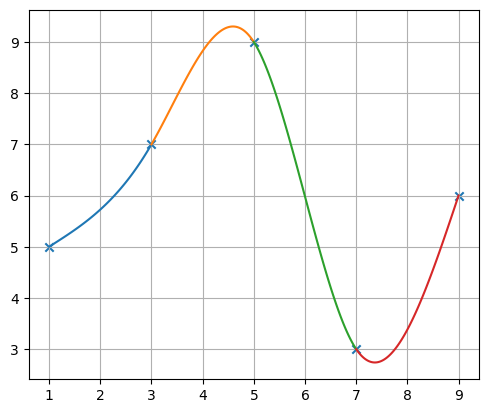

In [3]:
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.scatter(points[:,0], points[:,1], marker='x')
plt.grid(True)
for i in range(n):
    x = np.linspace(points[i,0], points[i+1,0], 100)
    xi = points[i,0]
    y = spline[0,i]*(x-xi)**3 + spline[1,i]*(x-xi)**2 +spline[2,i]*(x-xi) + spline[3,i]
    ax.plot(x,y)
plt.show()